In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

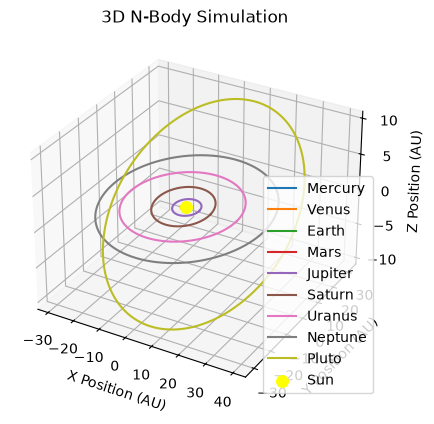

In [4]:
# Read the CSV file
data = pd.read_csv("Data/positions.csv")

dt = 0.001
N = 200000


labels = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
    "Pluto"
]

period = np.array([
    0.2408,    # Sun
    0.2408,    # Mercury
    0.6152,    # Venus
    1.0000,    # Earth
    1.8808,    # Mars
    11.862,    # Jupiter
    29.457,    # Saturn
    84.017,    # Uranus
    164.8,     # Neptune
    248.0      # Pluto
])


# Store positions
x_pos = np.zeros((len(labels), len(data)))
y_pos = np.zeros((len(labels), len(data)))
z_pos = np.zeros((len(labels), len(data)))


for i in range(len(labels)):

    x_pos[i, :] = data[labels[i] + "_x"].values
    y_pos[i, :] = data[labels[i] + "_y"].values
    z_pos[i, :] = data[labels[i] + "_z"].values


# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


for i in range(1, len(labels)):

    angle = np.unwrap(np.arctan2(y_pos[i, :], x_pos[i, :]))

    angle_change = angle - angle[0]

    orbit = np.where(angle_change >= 2*np.pi)[0]

    if len(orbit) > 0:
        steps = orbit[0]

        ax.plot(
            x_pos[i, :steps],
            y_pos[i, :steps],
            z_pos[i, :steps],
            label=labels[i]
        )
    else:
        ax.plot(
            x_pos[i, :],
            y_pos[i, :],
            z_pos[i, :],
            label=labels[i]
        )

ax.scatter(
    x_pos[0, 0],
    y_pos[0, 0],
    z_pos[0, 0],
    color='yellow',
    s=70,
    label='Sun'
)

ax.set_xlabel("X Position (AU)")
ax.set_ylabel("Y Position (AU)")
ax.set_zlabel("Z Position (AU)")

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)

ax.set_title("3D N-Body Simulation")

ax.legend()

plt.show()

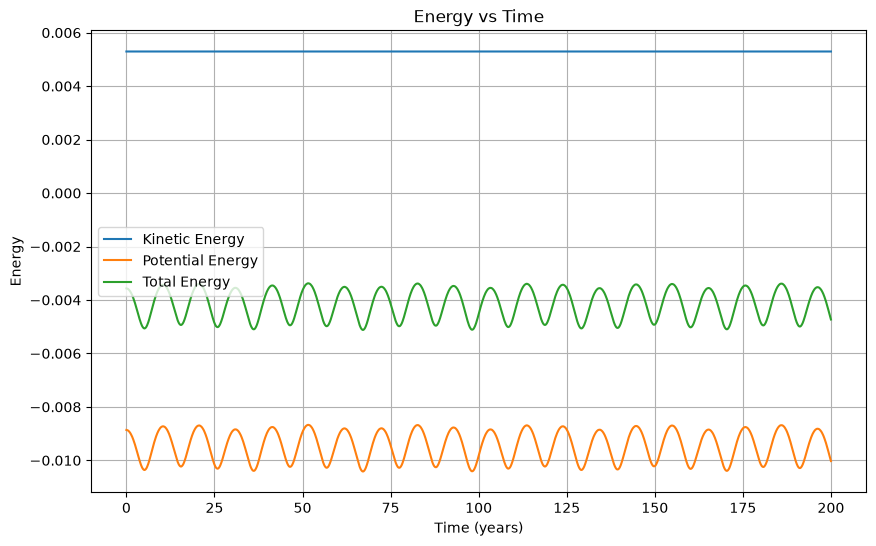

In [5]:
# Read energy data
data = pd.read_csv("Data/energy.csv")


# Time
time = np.arange(N) * dt


# Plot energy
plt.figure(figsize=(10, 6))

plt.plot(time, data["Kinetic Energy"], label="Kinetic Energy")
plt.plot(time, data["Potential Energy"], label="Potential Energy")
plt.plot(time, data["Total Energy"], label="Total Energy")

plt.xlabel("Time (years)")
plt.ylabel("Energy")
plt.title("Energy vs Time")

plt.legend()
plt.grid()

plt.show()